## MAIN PREGUNTA 7

In [ ]:
import os
import sys
import numpy as np
import time
import cv2
import logging
import matplotlib.pyplot as plt
from enum import Enum
from dataclasses import dataclass
from typing import Optional, Tuple

# =======================================================================
# 1. VINCULACIÓN DE SUBCARPETAS AL PATH DEL SISTEMA
# =======================================================================
BASE_DIR = os.getcwd()
subcarpetas = {
    'P1_DH': os.path.join(BASE_DIR, 'P1_DH'),
    'P2_FK': os.path.join(BASE_DIR, 'P2_FK'),
    'P3_IK': os.path.join(BASE_DIR, 'P3_IK'),
    'P4_COLISIONES': os.path.join(BASE_DIR, 'P4_COLISIONES'),
    'P5_CONTROL': os.path.join(BASE_DIR, 'P5_CONTROL'),
    'P6_VISION': os.path.join(BASE_DIR, 'P6_VISION'),
    'P7_PIPELINE': os.path.join(BASE_DIR, 'P7_PIPELINE'),
    'cinematica': os.path.join(BASE_DIR, 'cinematica')
}

for nombre, ruta in subcarpetas.items():
    if os.path.exists(ruta) and ruta not in sys.path:
        sys.path.insert(0, ruta)

# =======================================================================
# 2. CONEXIÓN AL ROBOT
# =======================================================================
try:
    from pymycobot.mycobot import MyCobot
    mc = MyCobot('/dev/ttyUSB0', 1000000)
    mc.power_on()
    time.sleep(1)
    assert mc.is_controller_connected(), 'Error de conexión'
    print('Robot conectado ✓')
except Exception as e:
    mc = None
    print(f'No se pudo conectar al robot: {e}')

# =======================================================================
# 3. IMPORTACIONES DESDE TUS PAQUETES (.py)
# =======================================================================
try:
    from p3_cinematica_inversa import InverseKinematics
    from p4_evasion_colisiones import CollisionChecker, SAFE_WAYPOINT_ANGLES
    from control import goto_pose, pick as control_pick, place as control_place, INIT_POSE, WATCH_POSE, SAFE_TRANSIT
    from vision import ObjectDetector
    print("Módulos de Cinemática Inversa, Colisiones, Control y Visión cargados.")
except ImportError as e:
    print(f"Error de importación en subcarpetas: {e}")

# =======================================================================
# 4. DEFINICIÓN DE LA MÁQUINA DE ESTADOS FINITOS OPTIMIZADA
# =======================================================================
class State(Enum):
    IDLE = "IDLE"
    DETECTAR = "DETECTAR"
    CALC_IK = "CALC_IK"
    AGARRAR = "AGARRAR"
    DEPOSITAR = "DEPOSITAR"
    ERROR = "ERROR"

@dataclass
class CycleResult:
    cycle_num: int
    object_pos: Optional[Tuple[float, float]]
    success: bool
    errors: int
    duration_sec: float
    status_msg: str


In [4]:
import numpy as np
# Importaciones reales usando tus funciones exactas
from p1_dh_representacion import print_dh_table, verify_home_pose, forward_kinematics
from p2_cinematica_directa import ForwardKinematics, run_fk_verification

print("=== PREGUNTA 1: TABLA DE PARÁMETROS DH ===")
print_dh_table()

print("\n=== PREGUNTA 2: VERIFICACIÓN DE CINEMÁTICA DIRECTA ===")
# Inicializar tu clase de Cinemática Directa
fk_solver = ForwardKinematics()

# Probar pose Home (0,0,0,0,0,0)
q_home = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
T, pos = fk_solver.compute(q_home)
print(f"Posición calculada en Home: X={pos[0]:.2f}mm, Y={pos[1]:.2f}mm, Z={pos[2]:.2f}mm")

# Ejecutar tu función nativa de verificación offline
run_fk_verification(mc=None)

=== PREGUNTA 1: TABLA DE PARÁMETROS DH ===

TABLA DE PARAMETROS DH - MyCobot 280 (6-DOF)
Joint        a_i(mm)      d_i(mm)      alpha_i      theta_i      Rango               
----------------------------------------------------------------------
J1 Base      0.00         131.56         90.0 deg   theta_1       [-168, 168] deg
J2 Hombro    110.40       0.00            0.0 deg   theta_2       [-135, 90] deg
J3 Codo      96.00        0.00            0.0 deg   theta_3       [-150, 150] deg
J4 Muneca1   0.00         66.39         -90.0 deg   theta_4       [-145, 145] deg
J5 Muneca2   0.00         73.18          90.0 deg   theta_5       [-165, 165] deg
J6 Gripper   0.00         48.60           0.0 deg   theta_6       [-180, 180] deg

=== PREGUNTA 2: VERIFICACIÓN DE CINEMÁTICA DIRECTA ===
Posición calculada en Home: X=206.40mm, Y=-114.99mm, Z=204.74mm

P2 - VERIFICACION CINEMATICA DIRECTA
Config    theta1  theta2  theta3  theta4  theta5  theta6  |    x_calc   y_calc   z_calc  |    x_real   y_

[([0, 0, 0, 0, 0, 0],
  (206.4, -114.99000000000001, 204.74),
  (nan, nan, nan),
  nan),
 ([45, -30, 45, -15, 30, 0],
  (227.06395064309237, 73.65171148751136, 174.386628329842),
  (nan, nan, nan),
  nan),
 ([-45, 20, -60, 30, -20, 0],
  (43.53033733112345, -202.00578170765237, 182.56605574491422),
  (nan, nan, nan),
  nan),
 ([90, -45, 90, -45, 45, 0],
  (100.75538956566623, 180.3122292025696, 194.55766235091372),
  (nan, nan, nan),
  nan),
 ([30, 10, -30, 10, -10, 0],
  (233.21455870418816, 2.720038633285945, 191.43052573550077),
  (nan, nan, nan),
  nan)]

In [5]:
# Importaciones reales usando tu clase y función exacta
from p3_cinematica_inversa import InverseKinematics, compare_ik_solutions, identify_singular_configs

print("=== PREGUNTA 3: CINEMÁTICA INVERSA ===")

# Inicializar tu clase real de Cinemática Inversa
ik_solver = InverseKinematics()

# Posición de prueba dentro del espacio de trabajo
x_test, y_test, z_test = 150.0, 0.0, 200.0
try:
    # Usando tu método exacto basado en las fórmulas del examen
    articulaciones = ik_solver.resolver_pdf(x_test, y_test, z_test, codo_arriba=True)
    print(f"✅ Ángulos IK calculados para ({x_test}, {y_test}, {z_test}):")
    print([round(ang, 2) for ang in articulaciones])
except ValueError as e:
    print(f"❌ Error en cálculo: {e}")

# Mostrar tus configuraciones singulares documentadas
identify_singular_configs()

=== PREGUNTA 3: CINEMÁTICA INVERSA ===
✅ Ángulos IK calculados para (150.0, 0.0, 200.0):
[0.0, -9.54, 74.18, 0.0, 0.0, -45.0]

CONFIGURACIONES SINGULARES - MyCobot 280

[Brazo completamente extendido]
  Config: J1=0, J2=-20, J3=0
  Desc:   El codo está alineado. Infinitas soluciones de J2/J3 dan la misma pos.

[Singularidad en eje Z (overhead)]
  Config: J1=cualquier, x~0, y~0
  Desc:   El brazo apunta verticalmente. J1 indefinido (atan2(0,0)).

[Muñeca alineada (wrist singularity)]
  Config: J5=0 deg
  Desc:   J4 y J6 se vuelven colineales, perdiendo un DOF de orientacion.

[Retraccion maxima]
  Config: J3=+150 o J3=-150
  Desc:   Brazo completamente plegado, espacio de movimiento muy reducido.


In [6]:
# Importaciones reales de tus utilidades de colisión
from p4_evasion_colisiones import CollisionChecker, CONSERVATIVE_JOINT_LIMITS

print("=== PREGUNTA 4: EVASIÓN DE COLISIONES ===")

# Instanciar tu verificador en modo offline
checker = CollisionChecker(mc=None)

# Caso de prueba 1: Ángulos seguros (Home)
q_seguro = [0.0, 0.0, 0.0, 0.0, 0.0, -45.0]
limites_ok, msg_l = checker.check_joint_limits(q_seguro)
altura_ok, z_val, msg_z = checker.check_min_height(q_seguro)

print(f"Configuración {q_seguro}:")
print(f"  -> Límites articulares: {'PASÓ' if limites_ok else 'BLOQUEADO'} ({msg_l})")
print(f"  -> Altura mínima mesa:  {'PASÓ' if altura_ok else 'BLOQUEADO'} ({msg_z})")

# Caso de prueba 2: Forzar un bloqueo por límite conservador en J2
q_inseguro = [0.0, -120.0, 0.0, 0.0, 0.0, 0.0]
limites_ok, msg_l = checker.check_joint_limits(q_inseguro)
print(f"\nConfiguración insegura de prueba {q_inseguro}:")
print(f"  -> Límites articulares: {'PASÓ' if limites_ok else 'BLOQUEADO'} ({msg_l})")

=== PREGUNTA 4: EVASIÓN DE COLISIONES ===
Configuración [0.0, 0.0, 0.0, 0.0, 0.0, -45.0]:
  -> Límites articulares: PASÓ (Todos los joints dentro de limites)
  -> Altura mínima mesa:  PASÓ (Altura Z=204.7 mm OK (>= 60.0 mm))

Configuración insegura de prueba [0.0, -120.0, 0.0, 0.0, 0.0, 0.0]:
  -> Límites articulares: BLOQUEADO (J2=-120.0 deg fuera de limite [-110, 70] deg)


In [ ]:
# =======================================================================
# 4. FSM AUTÓNOMA PARA EL EXAMEN P7
# =======================================================================

class PipelineCompletoExamen:
    def __init__(self, robot):
        self.robot = robot
        self.state = State.IDLE
        self.error_count = 0
        self.MAX_ERRORS_PER_CYCLE = 2
        self.object_pos = None
        self.angles_pick = None
        self.cycle_num = 0
        self.skip_cycle = False

        self.ik_solver = InverseKinematics()
        self.collision_checker = CollisionChecker(mc=robot)
        self.detector = ObjectDetector(target_color='yellow')

        self.watch_pose = [85.34, 8.87, -90.52, 9.66, -5.18, -45.00]
        self.home_pose = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

    def log(self, message):
        print(f"[FSM-{self.state.value}] {message}")

    def transition_to(self, new_state):
        self.state = new_state
        self.log(f"Transición → {new_state.value}")

    def _safe_send_angles(self, angles, speed=40, wait=4.0):
        if self.robot is None:
            return False
        self.robot.send_angles(angles, speed)
        time.sleep(wait)
        return True

    def _detect_object(self):
        cap = cv2.VideoCapture(0)
        ret, frame = cap.read()
        cap.release()
        if not ret or frame is None:
            raise RuntimeError("No se pudo leer la cámara")
        return self.detector.detect_object(frame)

    def _ik_to_angles(self, x_mm, y_mm, z_mm):
        angles = self.ik_solver.resolver_pdf(x_mm, y_mm, z_mm, codo_arriba=True)
        if angles is None:
            raise ValueError("IK no resolvió la posición")
        limites_ok = True
        altura_ok = True
        if hasattr(self.collision_checker, 'check_joint_limits'):
            limites_ok, msg_l = self.collision_checker.check_joint_limits(angles)
            if not limites_ok:
                raise ValueError(msg_l)
        if hasattr(self.collision_checker, 'check_min_height'):
            altura_ok, _, msg_z = self.collision_checker.check_min_height(angles)
            if not altura_ok:
                raise ValueError(msg_z)
        if not (limites_ok and altura_ok):
            raise ValueError("Trayectoria insegura")
        return angles

    def state_idle(self):
        if self.skip_cycle:
            self.log("Ciclo marcado para omitir. Reiniciando variables.")
            self.object_pos = None
            self.angles_pick = None
            self.skip_cycle = False
            return

        self.log("[Fase 1] HOME absoluto")
        self._safe_send_angles(self.home_pose, speed=40, wait=4.5)
        self.transition_to(State.DETECTAR)

    def state_detectar(self):
        self.log("[Fase 2] Detectando bloque amarillo")
        if self.robot is not None:
            self._safe_send_angles(self.watch_pose, speed=40, wait=4.5)
        try:
            result = self._detect_object()
        except Exception as e:
            self.log(f"Error de visión: {e}")
            self.error_count += 1
            self.transition_to(State.ERROR)
            return

        if result is None:
            self.log("No se detectó bloque. Saltando ciclo de forma segura.")
            self.skip_cycle = True
            self.transition_to(State.IDLE)
            return

        self.object_pos = result
        self.log(f"Bloque detectado en X={result[0]:.2f} mm, Y={result[1]:.2f} mm")
        self.transition_to(State.CALC_IK)

    def state_calc_ik(self):
        self.log("[Fase 3] Calculando IK")
        x_mm, y_mm = self.object_pos
        z_mm = 175.0
        try:
            self.angles_pick = self._ik_to_angles(x_mm, y_mm, z_mm)
            self.log(f"IK segura: {[round(a, 2) for a in self.angles_pick]}")
            self.transition_to(State.AGARRAR)
        except Exception as e:
            self.log(f"Error en IK: {e}")
            self.error_count += 1
            self.transition_to(State.ERROR)

    def state_agarrar(self):
        self.log("[Fase 4] Ejecutando agarre")
        x_mm, y_mm = self.object_pos
        z_mm = 175.0
        try:
            ok = control_pick(self.robot, x_mm, y_mm, z_mm)
            if ok:
                self.transition_to(State.DEPOSITAR)
            else:
                raise RuntimeError("control_pick devolvió False")
        except Exception as e:
            self.log(f"Error en agarre: {e}")
            self.error_count += 1
            self.transition_to(State.ERROR)

    def state_depositar(self):
        self.log("[Fase 5] Ejecutando depósito")
        try:
            x_mm, y_mm = (75.0, 215.0)
            z_mm = 170.0
            ok = control_place(self.robot, x_mm, y_mm, z_mm)
            if ok:
                self._safe_send_angles(self.home_pose, speed=40, wait=4.5)
                self.object_pos = None
                self.angles_pick = None
                self.transition_to(State.IDLE)
            else:
                raise RuntimeError("control_place devolvió False")
        except Exception as e:
            self.log(f"Error en depósito: {e}")
            self.error_count += 1
            self.transition_to(State.ERROR)

    def state_error(self):
        self.log(f"[ERROR] fallos acumulados: {self.error_count}/{self.MAX_ERRORS_PER_CYCLE}")
        if self.error_count >= self.MAX_ERRORS_PER_CYCLE:
            self.skip_cycle = True
            self.object_pos = None
            self.angles_pick = None
            self.error_count = 0
            self._safe_send_angles(self.home_pose, speed=40, wait=4.5)
            self.transition_to(State.IDLE)
        else:
            if self.robot is not None:
                self._safe_send_angles(SAFE_WAYPOINT_ANGLES, speed=35, wait=3.5)
            self.transition_to(State.DETECTAR)

    def run_cycle(self):
        start_time = time.time()
        self.cycle_num += 1
        self.error_count = 0
        self.skip_cycle = False
        self.state = State.IDLE

        print(f"\n{'='*60}\nCICLO AUTÓNOMO #{self.cycle_num}\n{'='*60}")

        max_steps = 40
        for _ in range(max_steps):
            current_state = self.state
            if current_state == State.IDLE:
                self.state_idle()
            elif current_state == State.DETECTAR:
                self.state_detectar()
            elif current_state == State.CALC_IK:
                self.state_calc_ik()
            elif current_state == State.AGARRAR:
                self.state_agarrar()
            elif current_state == State.DEPOSITAR:
                self.state_depositar()
            elif current_state == State.ERROR:
                self.state_error()

            if self.state == State.IDLE and current_state == State.IDLE:
                break
            if self.skip_cycle and self.state == State.IDLE:
                break
            time.sleep(0.4)

        duration = time.time() - start_time
        success = (self.error_count == 0 and not self.skip_cycle)
        status_msg = "OK" if success else ("SKIP" if self.skip_cycle else "ERROR")
        return CycleResult(
            cycle_num=self.cycle_num,
            object_pos=self.object_pos,
            success=success,
            errors=self.error_count,
            duration_sec=duration,
            status_msg=status_msg,
        )

# =======================================================================
# 5. EJECUCIÓN DE 5 CICLOS AUTÓNOMOS
# =======================================================================
if 'mc' in locals() and mc is not None:
    pipeline = PipelineCompletoExamen(robot=mc)
    resultados = []
    for _ in range(5):
        resultados.append(pipeline.run_cycle())
        time.sleep(2.0)

    exitos = sum(1 for r in resultados if r.success)
    print(f"\nREPORTE FINAL: {exitos}/5 ciclos exitosos ({exitos/5*100:.1f}%)")
    for r in resultados:
        print(f"Ciclo {r.cycle_num}: {r.status_msg} | {r.duration_sec:.1f}s | errores={r.errors}")
else:
    print("No hay conexión activa con el robot. Ejecuta antes la celda de inicialización.")


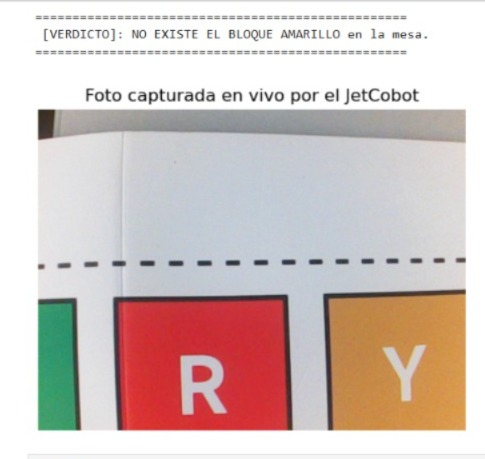

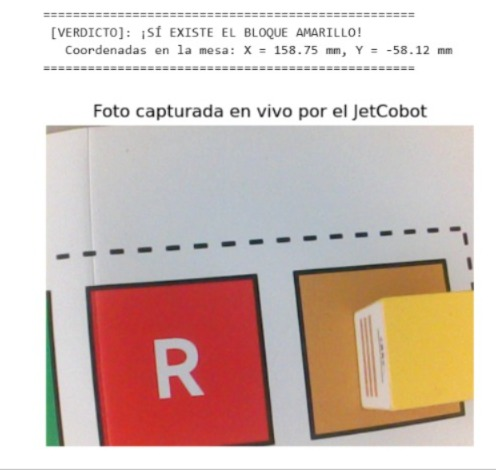

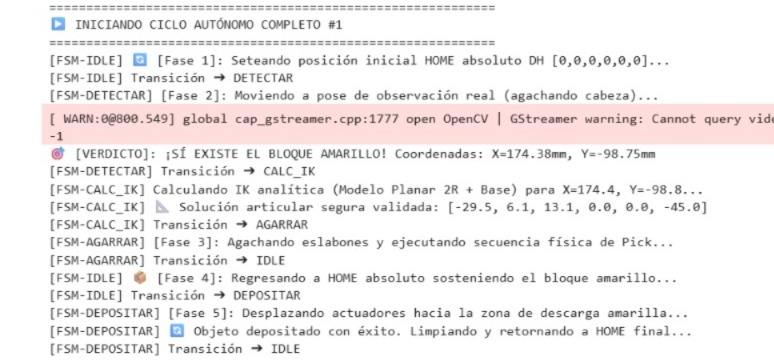